## ```numpy.random``` and random number generation

Random package has functions for random number generation and also for making samples from a given set.
There are still implementations that use the old version of random numeber genration:
```random``` function calculates a random number in the interval 0...1
```rand_int``` calculates a random integer in a given interval

Both functions are **uniform** generators meaning that all values are equally likely.
```seed``` function sets the internal state of the random number generator so, that for any give seed values the random number sequence is repeated. This is very useful when models are debugged.


However, newer code should use the `Generator` class from `numpy.random`. It is an improved version of the above mentioned functions. The class was introduced in `numpy 1.17.0`. You can check your version with `print(np.__version__)`


### Random integers and floats

The default algorithm of `Generator` can be instantiated with the function `numpy.random.default_rng`. 

In [62]:
from numpy.random import default_rng
rng = default_rng()
rng?

Type:        Generator
String form: Generator(PCG64)
File:        c:\users\jussi\anaconda3\lib\site-packages\numpy\random\_generator.cp311-win_amd64.pyd
Docstring:  
Generator(bit_generator)

Container for the BitGenerators.

``Generator`` exposes a number of methods for generating random
numbers drawn from a variety of probability distributions. In addition to
the distribution-specific arguments, each method takes a keyword argument
`size` that defaults to ``None``. If `size` is ``None``, then a single
value is generated and returned. If `size` is an integer, then a 1-D
array filled with generated values is returned. If `size` is a tuple,
then an array with that shape is filled and returned.

The function :func:`numpy.random.default_rng` will instantiate
a `Generator` with numpy's default `BitGenerator`.

**No Compatibility Guarantee**

``Generator`` does not provide a version compatibility guarantee. In
particular, as better algorithms evolve the bit stream may change.

Parameters
--

In [70]:
from numpy.random import default_rng
rng = default_rng()
ints = rng.integers(low=1, high=10, size=(1,15))
#low is included, but high is excluded
print("Random integers 1...9:\n",ints)
flts = rng.random(size = (1,10))
print("\nRandom floats between 0 ... 1")
print(flts)

a = 2 #scaling factor, from 0...1 to 0...a
b = 1 #shift, from 0...a to b...a+b
flts2 = a*rng.random(size = (1,10)) + b
print("\nRandom floats between 1 ... 3")
print(flts2)


Random integers 1...9:
 [[7 3 2 6 8 1 5 4 1 1 5 7 8 4 8]]

Random floats between 0 ... 1
[[0.99190599 0.21553474 0.84354534 0.00286036 0.753005   0.24718355
  0.68721619 0.81849424 0.50413741 0.45935299]]

Random floats between 1 ... 3
[[1.01172153 1.72227188 2.08952471 2.10743145 1.02131593 1.4506699
  1.89348281 2.41798288 1.76833669 2.19310128]]


It is also possible to specify the algorithm used in geration as below, but this is rarely needed. The default algorithm will be `PCG64` anyway.

In [55]:
from numpy.random import Generator, PCG64
rng = Generator(PCG64())
random_ints = rng.integers(low = 1, high = 10, size = (10,1))
print("Some random integers:")
print(random_ints.transpose())
random_floats = rng.random(size=(4,1)) #Default range (0,1)
print("\nSome random floats between 0.0 and 1.0:")
print(random_floats.transpose())


Some random integers:
[[4 4 4 9 5 4 9 5 4 4]]

Some random floats between 0.0 and 1.0:
[[0.71305437 0.52845728 0.24957015 0.06375224]]


## Random samples with `choice`

The random number genrators are applied when a random sample is needed.
The function ```choice``` generates a random sample from a given population (typically a list of values). 

It is possible to sample in two ways: A certain element can be selected more than once (**with replacement**) or a certain element can only be selected once **without replacement**

Assume that you have a bag of marbles and you draw a marble from the bag and keep record of the results. 
* **with replacement:** you put the marble that you have drawn back to the bag
* **without replacement:** you do not put the marble back to the back

In lottery seven numbers are sampled out of 40. This sampling is **without replacement**, because the same number is not allowed twice.

When tossing a coin several times the sampling is **with replacement** because both head and tail are possible in all tosses.

When sampling with replacement the next result is dependent of the previous one(s). This is because some element(s) will be missing. If sampling is made with replacement the next result is independent of the previous one(s).

In [61]:
rng.choice?

Docstring:
choice(a, size=None, replace=True, p=None, axis=0, shuffle=True)

Generates a random sample from a given array

Parameters
----------
a : {array_like, int}
    If an ndarray, a random sample is generated from its elements.
    If an int, the random sample is generated from np.arange(a).
size : {int, tuple[int]}, optional
    Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
    ``m * n * k`` samples are drawn from the 1-d `a`. If `a` has more
    than one dimension, the `size` shape will be inserted into the
    `axis` dimension, so the output ``ndim`` will be ``a.ndim - 1 +
    len(size)``. Default is None, in which case a single value is
    returned.
replace : bool, optional
    Whether the sample is with or without replacement. Default is True,
    meaning that a value of ``a`` can be selected multiple times.
p : 1-D array_like, optional
    The probabilities associated with each entry in a.
    If not given, the sample assumes a uniform distribution over a

# Example 
### Tossing a fair coin

A fair coin means that the two outcomes have the same probability $p=0.5$

In [91]:
import numpy as np

# Number of coin tosses to simulate
num_tosses = 1_000_000

# Create a random number generator
rng = np.random.default_rng()

# Simulate the coin tosses
tosses = rng.choice(['H', 'T'], size=num_tosses)

# Calculate the probabilities
heads_prob = np.sum(tosses == 'H') / num_tosses
tails_prob = 1 - heads_prob

print(f"Probability of Heads: {heads_prob:.5f}")
print(f"Probability of Tails: {tails_prob:.5f}")

Probability of Heads: 0.50056
Probability of Tails: 0.49944


### Tossing a biased coin

If the coin is biased then the outcomes have different probabilities.

In [97]:
from numpy.random import default_rng
from numpy import sum

# Define the bias of the coin (probability of heads)
bias = 0.6  # 60% chance of heads, 40% chance of tails

# Number of coin tosses to simulate
num_tosses = 1_000_000

# Create a random number generator
rng = np.random.default_rng()

# Simulate the coin tosses
tosses = rng.choice(['Heads', 'Tails'], size=num_tosses, p=[bias, 1 - bias])

# Calculate the probabilities
heads_prob = np.sum(tosses == 'Heads') / num_tosses
tails_prob = np.sum(tosses == 'Tails') / num_tosses

print(f"Probability of Heads: {heads_prob:.5f}")
print(f"Probability of Tails: {tails_prob:.5f}")


Probability of Heads: 0.59993
Probability of Tails: 0.40007


## Example - marbles in a bag - with or without replacement

We have 3 red, 2 green and 2 black marbles in a bag. Two marbles are drawn in succession without replacement. Find the probability that both are of the same color.

This means that a marble is drawn and put aside, then a second draw is done.

In [117]:
from numpy.random import default_rng

# Define the marbles in the bag
marbles = ['Red'] * 3 + ['Green'] * 2 + ['Black'] * 2  

# Number of simulations
num_simulations = 100_000

rng = default_rng()

# Counter for successful events (both marbles of the same color)
success_count = 0

# Simulate the drawing process
for _ in range(num_simulations):
    # Draw two marbles without replacement
    drawn_marbles = rng.choice(marbles, size=2, replace=False) 
    
    # Check if both marbles are of the same color
    if drawn_marbles[0] == drawn_marbles[1]:
        success_count += 1

# Calculate the probability
probability = success_count / num_simulations

print(f"Simulated probability that both marbles are of the same color: {probability:.4f}")

Simulated probability that both marbles are of the same color: 0.2398


If the sample is made with relacement, only the parameter `replace` is changed to `True`. Then the probability is `$P("\text{Same colors}") = 0.3463$


# Building a deck of cards with `itertools`

`itertools`is a built-in package.

In [50]:
import itertools as it
import matplotlib.pyplot as plt
import numpy as np

To build a deck of cards ```itertools``` can be used. The ```itertools.product``` forms all possible pairs of elements of two lists. 
To build a deck of cards strings corresponds to suit and integers or strings correspond to values. (The value could of course also be a string). ```itertools.product``` can use more than two lists, but the output will be large depending on the number of lists and their sizes.

Basically the output of ```itertools.product``` could be produced using nested ```for``` loops, but that woukd be slow.

In [119]:
from itertools import product
deck = list(product(['He','Cl','Di','Sp'],[1,2,3,4,5,6,7,8,9,10,11,12,13]))
for i in deck:
    print(i)

('He', 1)
('He', 2)
('He', 3)
('He', 4)
('He', 5)
('He', 6)
('He', 7)
('He', 8)
('He', 9)
('He', 10)
('He', 11)
('He', 12)
('He', 13)
('Cl', 1)
('Cl', 2)
('Cl', 3)
('Cl', 4)
('Cl', 5)
('Cl', 6)
('Cl', 7)
('Cl', 8)
('Cl', 9)
('Cl', 10)
('Cl', 11)
('Cl', 12)
('Cl', 13)
('Di', 1)
('Di', 2)
('Di', 3)
('Di', 4)
('Di', 5)
('Di', 6)
('Di', 7)
('Di', 8)
('Di', 9)
('Di', 10)
('Di', 11)
('Di', 12)
('Di', 13)
('Sp', 1)
('Sp', 2)
('Sp', 3)
('Sp', 4)
('Sp', 5)
('Sp', 6)
('Sp', 7)
('Sp', 8)
('Sp', 9)
('Sp', 10)
('Sp', 11)
('Sp', 12)
('Sp', 13)


Picking cards randomly can be done using `choice` method of the random generator or also by `numpy.random.shuffle`. `shuffle` will make a random permutation of cards in-place.

## Probability of drawing Ace of Hearts or Ace of Diamonds when two cards are drawn

In the code below the deck of cards is first formed using `itertools.product`. The function forms all possible combinations of two lists. After that the cards are drawn without replacement using `choice`.

In [ ]:
from numpy.random import default_rng
from itertools import product

deck = list(product(['He','Cl','Di','Sp'],[1,2,3,4,5,6,7,8,9,10,11,12,13)])

rng = default_rng()

n_shuffles = 100_000
count = 0

for i in range(n_shuffles):
    cards_drawn = rng.choice(deck, size = 2, replace = False)
    for card in cards_drawn:
        if all(card == ['Di','1']) or all(card == ['He','1']):
            count += 1
print(count/n_shuffles)        

0.07661


In [161]:
#Exact result  
print("P = ",1 - 50/52*49/51) #Anything else than He1 or Di1 in the 1st draw is 50/52 and in the second draw 49/51

P =  0.07616892911010564


## Probability of drawing an Ace in a single draw

In [7]:

nShuffles = 1000000
count = 0
for i in range(nShuffles):
    np.random.shuffle(deck)
    if deck[0][1] == 1:
        count+=1
print(count/nShuffles)

0.077284


In [8]:
#Exact result
print("P = ",4/52)


P =  0.07692307692307693


# Number of faulty products in a sample

Assume that a component is of unacceptable quality with the probability of 0.1. Take a sample of 50 units and find the probabilities of number of bad components.

Number of bad components in a sample of 50 can be anything between 0 and 50. Of course it is easy to estimate that on the average there should be around $ 50\cdot0.1 = 5 $ bad components.

We can simulate the probabilities by creating many samples of size 50 and counting how many bad components we find.



Average: 5.0


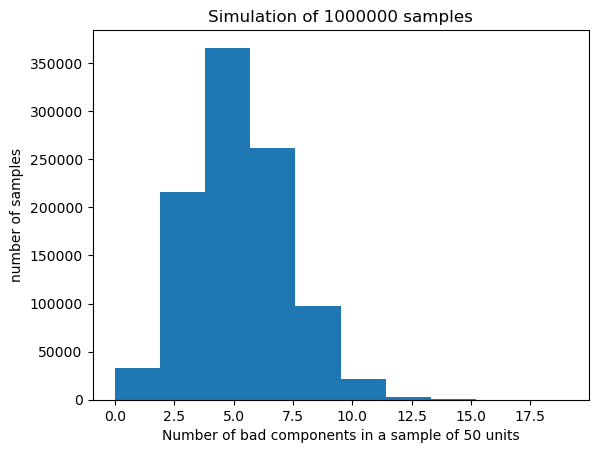

In [71]:
sampleSize = 50
threshold = 0.1
nSamples = 1000_000

#values less than or equal to threshold correspond to bad components
nBad = np.zeros(nSamples)
for i in range(nSamples):
    batch = np.random.uniform(0,1,sampleSize)
    nBad[i] = sum(1 for x in batch if x <= threshold)

print(f"Average: {np.average(nBad):0.1f}")
plt.hist(x=nBad,histtype='barstacked')
plt.title(f"Simulation of {nSamples} samples")
plt.xlabel("Number of bad components in a sample of 50 units")
plt.ylabel("number of samples")

plt.show()